In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, f1_score
)

%matplotlib inline

In [2]:
train = pd.read_csv('../data/processed/training_xgb_rf.csv')
test  = pd.read_csv('../data/processed/test_xgb_rf.csv')

X_train = train.drop(columns=['label'])
y_train = train['label']
X_test  = test.drop(columns=['label'])
y_test  = test['label']

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Class balance (train) — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}')

Train: (55945, 58), Test: (107740, 58)
Class balance (train) — 0: 34206, 1: 21739


In [3]:
base_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

## Hyperparameter Tuning

In [4]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 8],
    'max_features':      ['sqrt', 'log2', 0.3, 0.5],
    'bootstrap':         [True, False],
}

search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print(f'Best ROC-AUC (CV): {search.best_score_:.4f}')
print(f'Best params:       {search.best_params_}')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best ROC-AUC (CV): 0.9871
Best params:       {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30, 'bootstrap': False}


In [5]:
model = search.best_estimator_

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Base Evaluation, threshold = 0.5

In [6]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

              precision    recall  f1-score   support

      Normal       0.78      0.98      0.87     51890
      Attack       0.98      0.75      0.85     55850

    accuracy                           0.86    107740
   macro avg       0.88      0.86      0.86    107740
weighted avg       0.88      0.86      0.86    107740

ROC-AUC: 0.9736


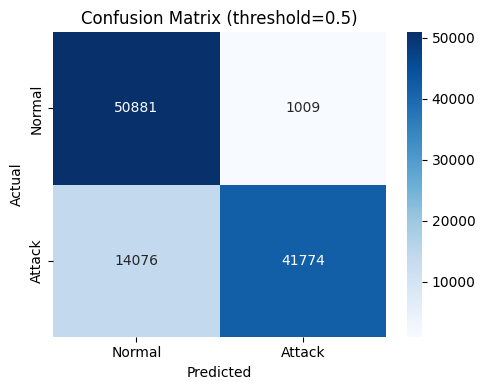

In [7]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
ax.set_title('Confusion Matrix (threshold=0.5)')
plt.tight_layout()
plt.show()

## Threshold Tuning

In cybersecurity, false negatives (missed attacks) are more costly than false positives.
We find the threshold that maximises F1, then also examine the recall-precision tradeoff.

Optimal threshold (max F1): 0.04  — F1: 0.9091
Default threshold (0.5):           — F1: 0.8471


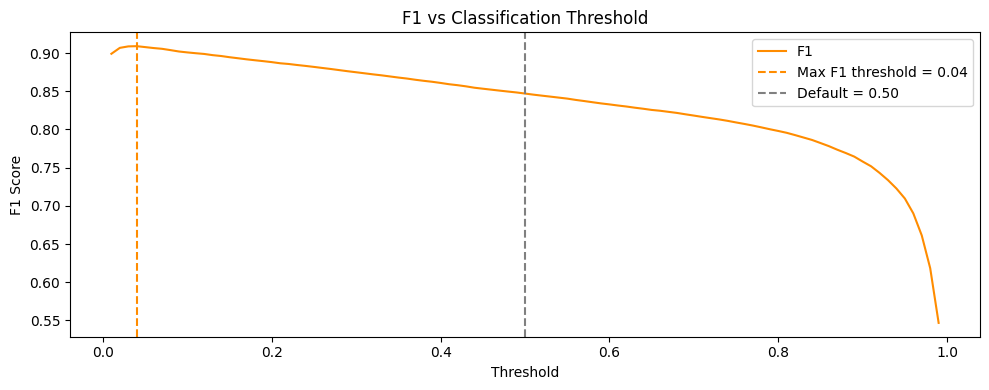

In [8]:
thresholds = np.arange(0.01, 1.0, 0.01)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int)) for t in thresholds]

best_f1_threshold = thresholds[np.argmax(f1_scores)]

print(f'Optimal threshold (max F1): {best_f1_threshold:.2f}  — F1: {max(f1_scores):.4f}')
print(f'Default threshold (0.5):           — F1: {f1_scores[49]:.4f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, f1_scores, color='darkorange', label='F1')
ax.axvline(best_f1_threshold, color='darkorange', linestyle='--', label=f'Max F1 threshold = {best_f1_threshold:.2f}')
ax.axvline(0.5, color='gray', linestyle='--', label='Default = 0.50')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('F1 vs Classification Threshold')
ax.legend()
plt.tight_layout()
plt.show()

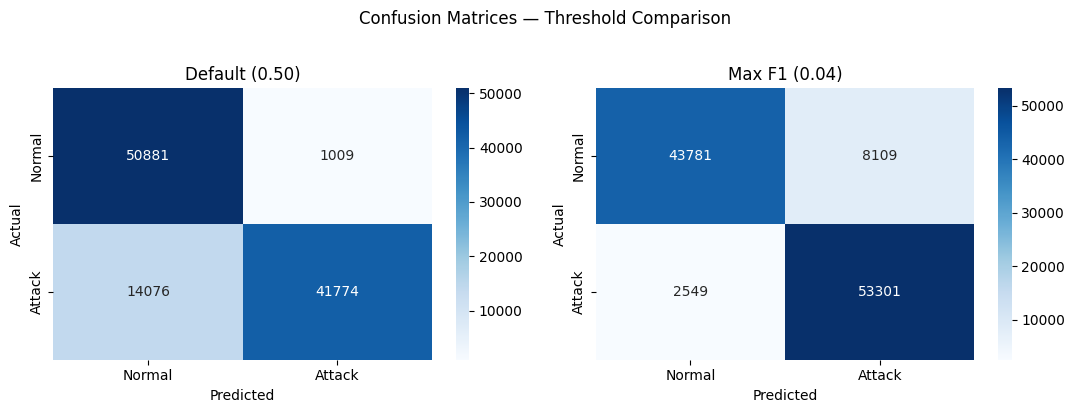


Chosen threshold: 0.04 (max F1)
              precision    recall  f1-score   support

      Normal       0.94      0.84      0.89     51890
      Attack       0.87      0.95      0.91     55850

    accuracy                           0.90    107740
   macro avg       0.91      0.90      0.90    107740
weighted avg       0.91      0.90      0.90    107740



In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (t, title) in zip(axes, [
    (0.5,               'Default (0.50)'),
    (best_f1_threshold, f'Max F1 ({best_f1_threshold:.2f})'),
]):
    preds = (y_prob >= t).astype(int)
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    ax.set_title(title)
plt.suptitle('Confusion Matrices — Threshold Comparison', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nChosen threshold: {best_f1_threshold:.2f} (max F1)')
print(classification_report(y_test, (y_prob >= best_f1_threshold).astype(int), target_names=['Normal', 'Attack']))

In [10]:
y_pred_tuned = (y_prob >= best_f1_threshold).astype(int)

## Per-Attack-Category Breakdown

Join predictions against the raw test data to evaluate performance per attack type.

In [11]:
raw_test = pd.read_csv('../data/raw/UNSW_NB15_testing-set.csv')
raw_test = raw_test.drop_duplicates(subset=[c for c in raw_test.columns if c != 'id']).reset_index(drop=True)

results = raw_test[['attack_cat']].copy()
results['y_true'] = y_test.values
results['y_pred'] = y_pred_tuned
results['y_prob'] = y_prob

results.head()

,attack_cat,y_true,y_pred,y_prob
0,Normal,0,1,0.889079
1,Normal,0,1,0.938602
2,Normal,0,1,0.965767
3,Normal,0,1,0.819119
4,Normal,0,1,0.365330


In [12]:
def attack_metrics(group):
    tp = ((group['y_true'] == 1) & (group['y_pred'] == 1)).sum()
    fn = ((group['y_true'] == 1) & (group['y_pred'] == 0)).sum()
    fp = ((group['y_true'] == 0) & (group['y_pred'] == 1)).sum()
    tn = ((group['y_true'] == 0) & (group['y_pred'] == 0)).sum()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return pd.Series({'count': len(group), 'precision': round(precision, 4),
                      'recall': round(recall, 4), 'f1': round(f1, 4)})

attack_results = results[results['attack_cat'] != 'Normal']
breakdown = attack_results.groupby('attack_cat').apply(attack_metrics, include_groups=False).sort_values('recall')
print(breakdown.to_string())

                  count  precision  recall      f1
attack_cat                                        
Analysis         1594.0        1.0  0.8614  0.9255
Fuzzers         16150.0        1.0  0.8614  0.9255
Shellcode        1091.0        1.0  0.9963  0.9982
Exploits        19844.0        1.0  0.9964  0.9982
DoS              3806.0        1.0  0.9982  0.9991
Generic          4181.0        1.0  0.9986  0.9993
Reconnaissance   7522.0        1.0  0.9999  0.9999
Backdoor         1535.0        1.0  1.0000  1.0000
Worms             127.0        1.0  1.0000  1.0000


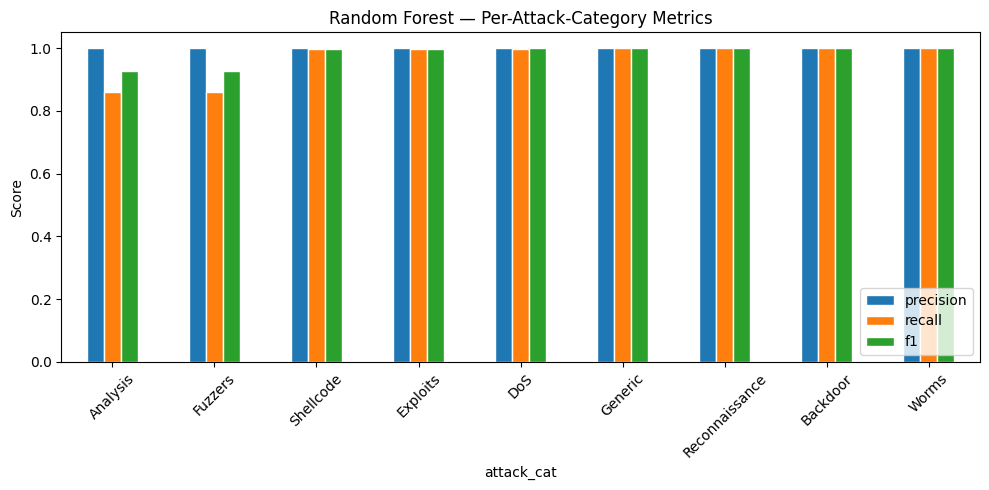

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
breakdown[['precision', 'recall', 'f1']].plot(kind='bar', ax=ax, edgecolor='white')
ax.set_title('Random Forest — Per-Attack-Category Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Feature Importance

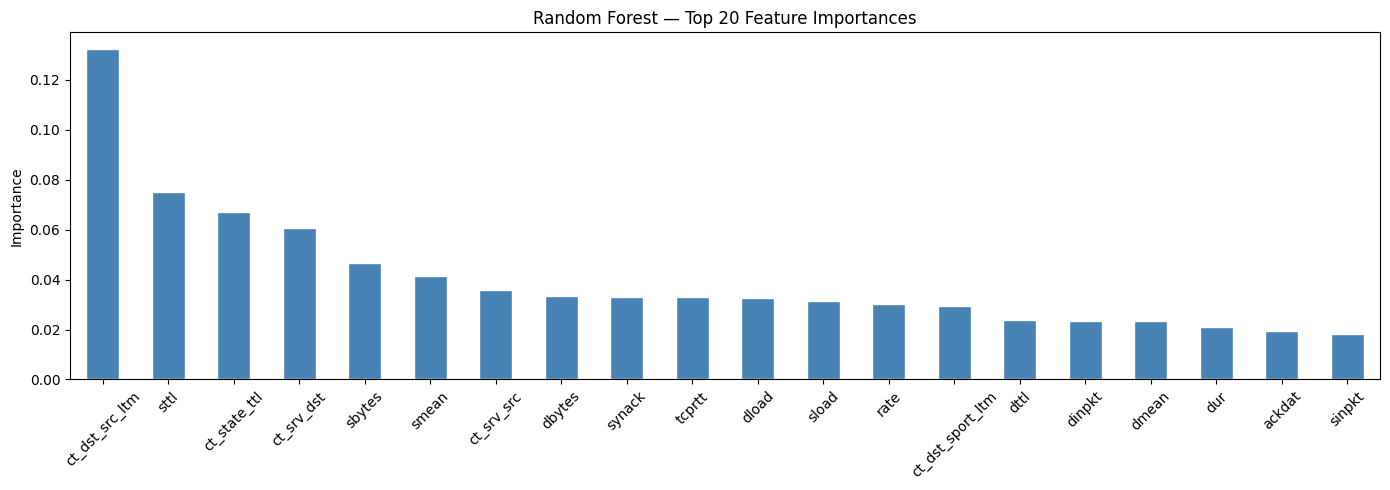

In [14]:
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
importances.head(20).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest — Top 20 Feature Importances')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()